In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cns.data_utils import main_load, save_cns_fig
from cns.process import get_breaks_from_cns_df

plt.rcParams.update({'font.size': 12 })


c:\Python39\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
samples_df, cns_df = main_load()

In [4]:
dict_start = get_breaks_from_cns_df(cns_df, False)
# Step 1: Convert the dictionary to a DataFrame
df = pd.DataFrame.from_dict(dict_start, orient='index').transpose()

# Step 2: Calculate the breakpoints per chromosome
breakpoints_per_chr = pd.DataFrame({
    'Chromosome': list(dict_start.keys()),
    'Breakpoints': [len(value) for value in dict_start.values()]
}).set_index('Chromosome')

# Step 3: Calculate the total breakpoints
total_breakpoints = breakpoints_per_chr['Breakpoints'].sum()

# Step 4: Display the DataFrame and the total breakpoints
print("Breakpoints per chromosome:")
print(breakpoints_per_chr)
print("\nTotal breakpoints:", total_breakpoints)

TypeError: 'NoneType' object is not subscriptable

In [ ]:
def break_count(breaks):
    return sum(len(values) for values in breaks.values())

In [ ]:
import time

from cns.process.cluster import calc_clusters, cluster_within_segments
from cns.utils.conversions import genome_to_segments
chr_clusters = {}
orig_count = break_count(dict_start)
print(f"Reducing {orig_count} breakpoints:")
distances =  [1000 * (2**i) for i in range(11)] 
counts = []
gen_segs = genome_to_segments()
for dist in distances:
    time_start = time.time()
    res = calc_clusters(dict_start, dist)
    counts.append(break_count(res))
    reduction = np.round(counts[-1] / orig_count * 100, 2)
    print(f"Dist: {dist}, count: {counts[-1]}, ratio: {reduction}%, time: {time.time() - time_start:.2f}s")

Reducing 826841 breakpoints:
Dist: 1000, count: 611942, ratio: 74.01%, time: 171.57s
Dist: 2000, count: 478642, ratio: 57.89%, time: 189.36s
Dist: 4000, count: 324730, ratio: 39.27%, time: 117.39s
Dist: 8000, count: 194376, ratio: 23.51%, time: 39.66s
Dist: 16000, count: 108819, ratio: 13.16%, time: 12.13s
Dist: 32000, count: 58458, ratio: 7.07%, time: 5.57s
Dist: 64000, count: 30357, ratio: 3.67%, time: 3.12s
Dist: 128000, count: 15484, ratio: 1.87%, time: 1.88s
Dist: 256000, count: 7838, ratio: 0.95%, time: 1.40s
Dist: 512000, count: 3968, ratio: 0.48%, time: 1.19s
Dist: 1024000, count: 2003, ratio: 0.24%, time: 1.00s


[ 9.96578428 10.96578428 11.96578428 12.96578428 13.96578428 14.96578428
 15.96578428 16.96578428 17.96578428 18.96578428 19.96578428]


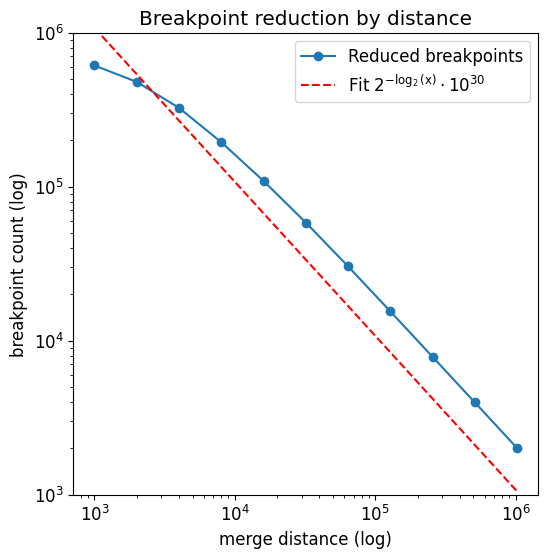

In [ ]:
# set plot to 6x6
fig = plt.figure(figsize=(6, 6))
# Step 1: Perform linear regression on the log-transformed data
log_distances = np.log2(distances)
log_counts = np.log2(counts)
slope, intercept = np.polyfit(log_distances, log_counts, 1)
print(log_distances)
# Step 2: Generate the linear fit line
fit_line = 2**(-1 * log_distances + 30.5)
# Step 3: Plot the original data and the fit line
plt.plot(distances, counts, marker='o', label='Reduced breakpoints')
hand_fit = 2**(-log_distances)*2**30
hand_label = r'Fit $2^{-\log_2(\text{x})} \cdot 10^{30}$'
plt.plot(distances, hand_fit, linestyle='--', color='r', label=hand_label)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e3, 1e6)
plt.xlabel('merge distance (log)')
plt.ylabel('breakpoint count (log)')
plt.title('Breakpoint reduction by distance')
plt.legend()
plt.show()
save_cns_fig("breakpoint_reduction", fig)